# Gaming Laptops Q1 2026 -- End-to-End AI and ML Pipeline
Uplift Code Camp | Portfolio Project

---

Dataset: ~614 laptop and PC product listings scraped from Amazon (Q1 2026)

Goal: Build a complete data science pipeline from raw data to AI-enriched insights.

| Technique | Category | Purpose |
|---|---|---|
| EDA + Visualization | Analysis | Understand the raw data |
| Data Cleaning | Preprocessing | Fix missing values and inconsistencies |
| Feature Engineering | Preprocessing | Create new useful columns from existing ones |
| NLP: Spec Extraction | NLP / Text Analysis | Parse structured specs from unstructured product titles |
| Zero-Shot Classification | LLM / NLP | Classify products using Claude API -- no training needed |
| Linear Regression | Supervised ML | Predict product price |
| Random Forest Classifier | Supervised ML | Predict price tier |
| KMeans + Elbow Method | Unsupervised ML | Group products into natural market segments |
| PCA | Dimensionality Reduction | Compress and visualize high-dimensional features |

---


## Table of Contents

- [Step 0 -- Setup and Environment](#step0)
- [Step 1 -- Load Data](#step1)
- [Step 2 -- Exploratory Data Analysis](#step2)
- [Step 3 -- Data Cleaning](#step3)
- [Step 4a -- Feature Engineering](#step4a)
- [Step 4b -- NLP: Extract Specs from Titles](#step4b)
- [Step 5 -- Zero-Shot Classification (Claude API)](#step5)
- [Step 6 -- Encode](#step6)
- [Step 7 -- Split and Scale](#step7)
- [Step 8 -- Train and Evaluate](#step8)
  - 8a. Regression: Predict Price
  - 8b. Classification: Predict Price Tier
  - 8c. Clustering: KMeans + Elbow Method
  - 8d. Dimensionality Reduction: PCA
- [Step 9 -- Export Final CSV](#step9)


## Step 0: Setup and Environment <a id='step0'></a>


In [ ]:
import sys
IS_COLAB = 'google.colab' in sys.modules
print('Environment:', 'Google Colab' if IS_COLAB else 'VS Code / Local')

# Uncomment if you are in Google Colab and packages are not yet installed:
!pip install anthropic pandas scikit-learn matplotlib seaborn python-dotenv -q


Environment: Google Colab


### Unzip Dataset

Use this cell if you are working in Google Colab with a zipped dataset from Google Drive.

Instructions:
1. Upload archive.zip to Google Drive
2. In Colab, mount your Drive using the folder icon in the left sidebar
3. Update zip_path to your actual Drive path
4. Run this cell

VS Code users: place the CSV directly in your project folder and skip this cell.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_file_path  = r'/content/drive/MyDrive/Python Bootcamp Uplift/0427 Gaming Laptops 2026/archive.zip'
file_folder_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/0427 Gaming Laptops 2026/'

with zipfile.ZipFile(zip_file_path) as zip_ref:
    zip_ref.extractall(file_folder_path)

print('Archive extracted')

Archive extracted


In [ ]:
!pip install anthropic

In [ ]:
# All imports used throughout this notebook

import re                    # regular expressions -- used in the NLP step
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anthropic             # Claude API -- used in the zero-shot step
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, confusion_matrix
)

# --- API Key ---
# Choose the method that matches your environment.
#
# Google Colab (keeps key out of the notebook):
#   1. Click the key icon in the left sidebar
#   2. Add a secret named CLAUDE_API_KEY
#   3. Uncomment:
# from google.colab import userdata
# CLAUDE_API_KEY = userdata.get('CLAUDE_API_KEY')
#
# VS Code (never commit .env to GitHub):
#   1. Create a .env file in your project folder
#   2. Add one line: CLAUDE_API_KEY=your-key-here
#   3. Uncomment:
# from dotenv import load_dotenv
# load_dotenv()
# import os
# CLAUDE_API_KEY = os.getenv('CLAUDE_API_KEY')

from google.colab import userdata
CLAUDE_API_KEY = userdata.get('CLAUDE_API_KEY')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Imports loaded.')


Imports loaded.


## Step 1: Load Data <a id='step1'></a>


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Python Bootcamp Uplift/0427 Gaming Laptops 2026/gaming_laptops_2026_q1.csv')

print('Shape:', df.shape[0], 'rows x', df.shape[1], 'columns')
print('Columns:', list(df.columns))
df.head(5)


Shape: 614 rows x 10 columns
Columns: ['title', 'brand', 'price', 'list_price', 'discount_pct', 'price_currency', 'stars', 'reviews_count', 'breadCrumbs', 'description']


,title,brand,price,list_price,discount_pct,price_currency,stars,reviews_count,breadCrumbs,description
0,Apple 2025 MacBook Air 13-inch Laptop with M4 ...,Apple,949.00,999.00,5.01,$,4.8,5991,NaN,NaN
1,Apple 2025 MacBook Pro Laptop with M5 chip wit...,Apple,1449.00,1599.00,9.38,$,4.7,1217,NaN,NaN
2,Lenovo Legion Pro 7i – AI-Powered Gaming Lapto...,Lenovo,2004.89,2149.99,6.75,$,4.3,139,Electronics > Computers & Accessories > Comput...,The Lenovo Legion Pro 7i is designed for eSpor...
3,LG 45GX950A-B 45-inch Ultragear 5K2K WUHD (512...,LG,1486.99,1999.99,25.65,$,4.3,323,Electronics > Computers & Accessories > Monitors,Unleash unparalleled gaming prowess with the w...
4,acer Nitro V Gaming Laptop | Intel Core i7-136...,acer,949.99,NaN,0.00,$,4.6,205,Electronics > Computers & Accessories > Comput...,Live For Victory: Elevate your gaming adventur...


---
## Step 2: Exploratory Data Analysis (EDA) <a id='step2'></a>

EDA is the first thing you do with any new dataset.
The goal is to understand the shape, distributions, and quality of your data before modifying anything.
Skipping EDA often leads to hidden problems in later steps.


In [ ]:
print('Data types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Numeric column statistics:')
df[['price', 'list_price', 'discount_pct', 'stars', 'reviews_count']].describe().round(2)


Data types:
title              object
brand              object
price             float64
list_price        float64
discount_pct      float64
price_currency     object
stars             float64
reviews_count       int64
breadCrumbs        object
description        object
dtype: object

Missing values per column:
title               0
brand               0
price               0
list_price        499
discount_pct        0
price_currency      0
stars             116
reviews_count       0
breadCrumbs        12
description       142
dtype: int64

Numeric column statistics:


,price,list_price,discount_pct,stars,reviews_count
count,614.00,115.00,614.00,498.00,614.00
mean,1651.40,1747.85,3.31,4.41,97.42
std,778.56,651.54,8.53,0.54,432.43
min,778.00,899.00,0.00,1.00,0.00
25%,1034.74,1266.49,0.00,4.20,1.00
50%,1449.00,1599.99,0.00,4.40,9.00
75%,2003.66,2124.99,0.00,4.80,38.00
max,5859.00,4399.99,44.80,5.00,6382.00


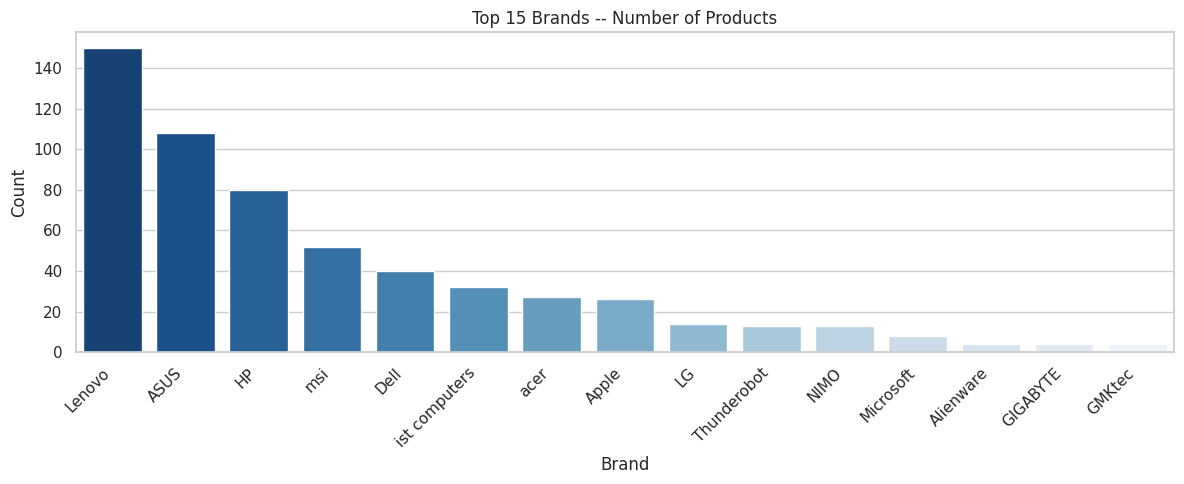

In [ ]:
# Chart 1: Top 15 brands by product count

top_brands = df['brand'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='Blues_r')
plt.title('Top 15 Brands -- Number of Products')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


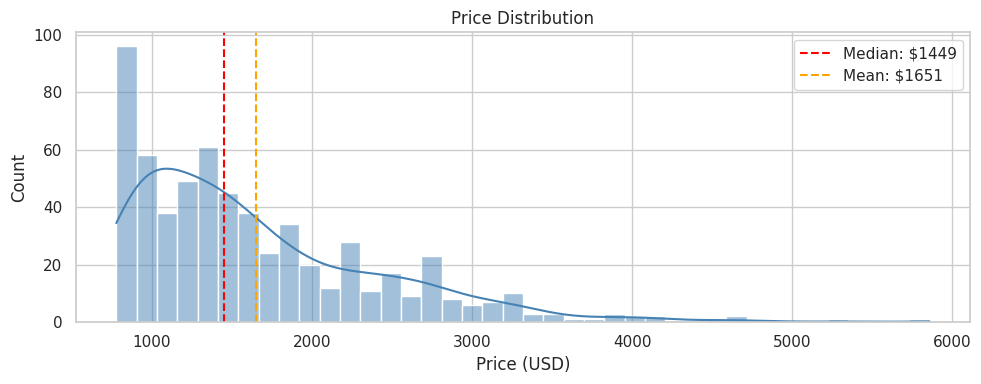

In [ ]:
# Chart 2: Price distribution
# A histogram shows how frequently each price range appears.
# The KDE line (smooth curve) shows the overall shape of the distribution.

plt.figure(figsize=(10, 4))
sns.histplot(df['price'], bins=40, kde=True, color='steelblue')
plt.axvline(df['price'].median(), color='red',    linestyle='--',
            label='Median: $' + str(round(df['price'].median())))
plt.axvline(df['price'].mean(),   color='orange', linestyle='--',
            label='Mean: $'   + str(round(df['price'].mean())))
plt.title('Price Distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


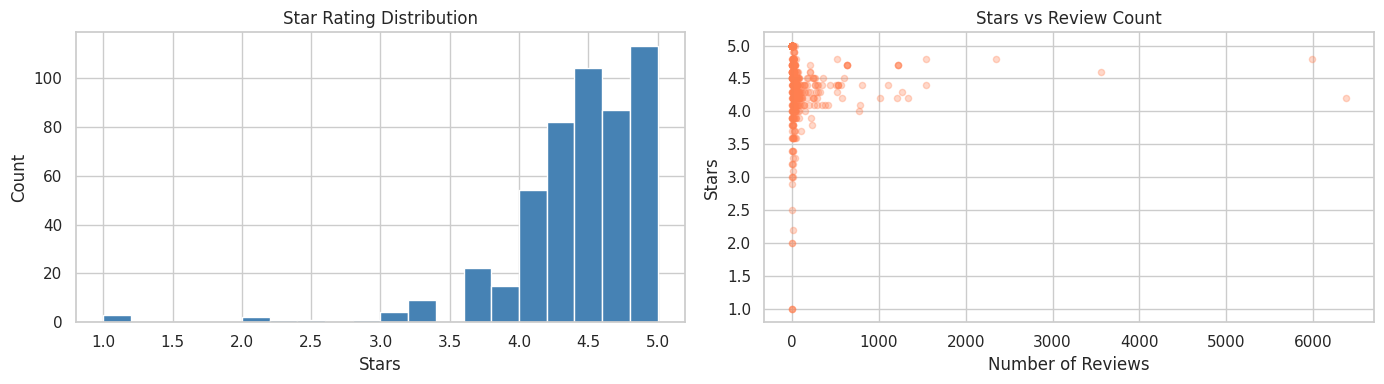

Products with 5.0 stars: 109
Average reviews for 5-star products: 3.1


In [ ]:
# Chart 3: Stars distribution and stars vs review count
# Note: 109 products have exactly 5.0 stars with very few reviews.
# These are likely newly listed products, not genuinely top-rated.
# This kind of observation only surfaces when you look at the data carefully.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['stars'].dropna().hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Star Rating Distribution')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')

axes[1].scatter(df['reviews_count'], df['stars'], alpha=0.3, color='coral', s=20)
axes[1].set_title('Stars vs Review Count')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Stars')

plt.tight_layout()
plt.show()

five_star = df[df['stars'] == 5.0]
print('Products with 5.0 stars:', len(five_star))
print('Average reviews for 5-star products:', round(five_star['reviews_count'].mean(), 1))


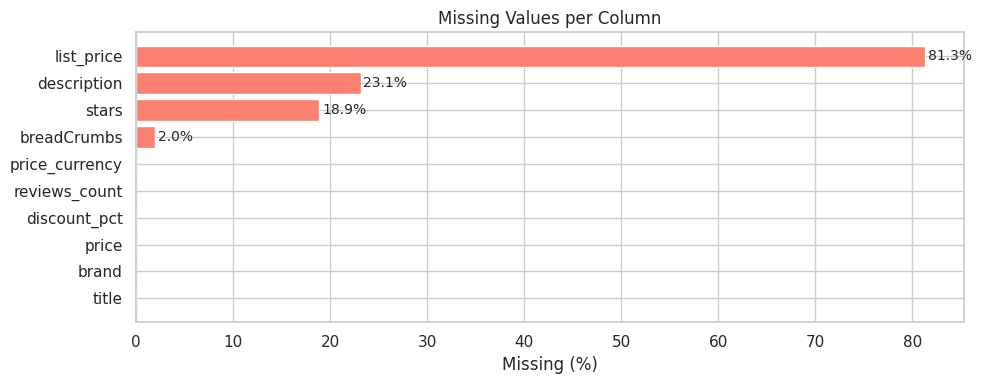

In [ ]:
# Chart 4: Missing values per column (shown as percentage)

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_pct.index, missing_pct.values, color='salmon')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Column')
for bar, val in zip(bars, missing_pct.values):
    if val > 0:
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                str(round(val, 1)) + '%', va='center', fontsize=10)
plt.tight_layout()
plt.show()


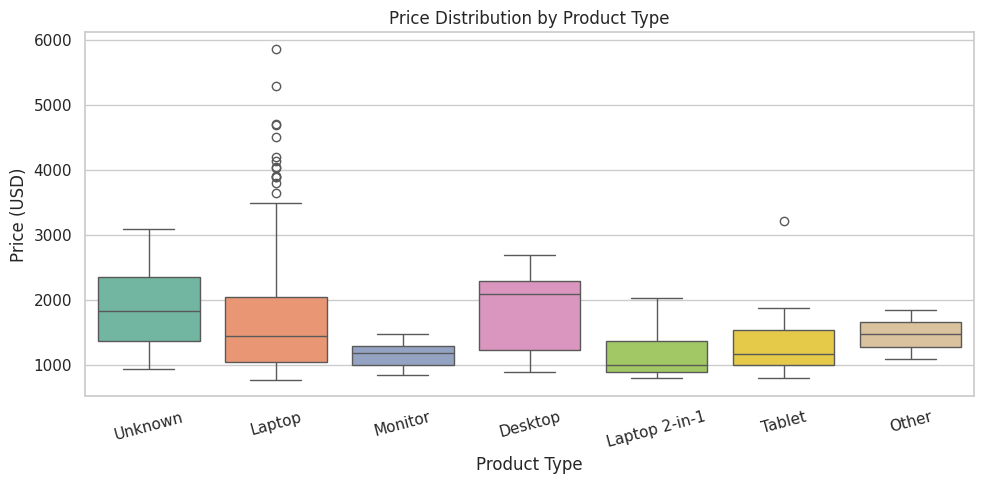

In [ ]:
# Chart 5: Price by product type
# Extract product type from breadCrumbs to compare price distributions across categories.

def extract_type(crumb):
    if pd.isna(crumb): return 'Unknown'
    crumb = crumb.lower()
    if '2 in 1' in crumb: return 'Laptop 2-in-1'
    if 'laptop'  in crumb: return 'Laptop'
    if 'desktop' in crumb: return 'Desktop'
    if 'monitor' in crumb: return 'Monitor'
    if 'tablet'  in crumb: return 'Tablet'
    return 'Other'

df['_product_type'] = df['breadCrumbs'].apply(extract_type)

plt.figure(figsize=(10, 5))
sns.boxplot(x='_product_type', y='price', data=df, palette='Set2')
plt.title('Price Distribution by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Price (USD)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


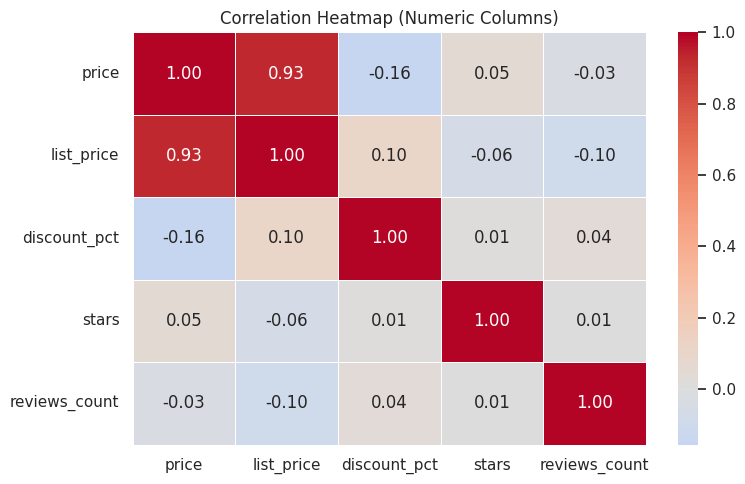

In [ ]:
# Chart 6: Correlation heatmap
# Correlation measures the linear relationship between two numeric columns.
# Range: -1.0 (perfect inverse) to 1.0 (perfect positive). 0.0 means no relationship.

numeric_cols = df[['price', 'list_price', 'discount_pct', 'stars', 'reviews_count']]

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Columns)')
plt.tight_layout()
plt.show()


### EDA Observations

| Observation | Implication |
|---|---|
| Lenovo (150), ASUS (108), HP (80) are the top three brands | Dataset skews toward major laptop brands |
| Price median ~$1,449, mean ~$1,651 | Right-skewed: a few expensive products pull the mean up |
| 499 of 614 rows have no list_price | Most products have no original price -- discount_pct is 0 for these |
| 109 products have 5.0 stars with very few reviews | Likely newly listed -- not reliably rated |
| 142 rows have no description | Mostly Apple products, which lack Amazon seller descriptions |
| price and list_price are highly correlated | Expected -- both represent pricing for the same product |


---
## Step 3: Data Cleaning <a id='step3'></a>

Cleaning handles missing values, wrong data types, and naming inconsistencies.
We always work on a copy of the original so the raw data stays intact for reference.


In [ ]:
df_clean = df.copy()

# Fill missing list_price with price
# If no original price is listed, we treat the current price as the baseline.
df_clean['list_price'] = df_clean['list_price'].fillna(df_clean['price'])

# Fill missing stars with the median
# We use median rather than mean because star ratings are on a fixed 1-5 scale.
median_stars = df_clean['stars'].median()
df_clean['stars'] = df_clean['stars'].fillna(median_stars)
print('Filled', df['stars'].isnull().sum(), 'missing star ratings with median:', median_stars)

# Fill missing reviews_count with 0
df_clean['reviews_count'] = df_clean['reviews_count'].fillna(0).astype(int)

# Fill missing text columns with empty string
df_clean['description'] = df_clean['description'].fillna('')
df_clean['breadCrumbs'] = df_clean['breadCrumbs'].fillna('Unknown')

# Standardize brand capitalization
# The same brand appears differently: 'msi' vs 'MSI', 'acer' vs 'Acer', etc.
brand_corrections = {'msi': 'MSI', 'acer': 'Acer', 'lg': 'LG'}
df_clean['brand'] = df_clean['brand'].str.strip().replace(brand_corrections)

print()
print('Missing values after cleaning:')
print(df_clean.isnull().sum())


Filled 116 missing star ratings with median: 4.4

Missing values after cleaning:
title             0
brand             0
price             0
list_price        0
discount_pct      0
price_currency    0
stars             0
reviews_count     0
breadCrumbs       0
description       0
_product_type     0
dtype: int64


---
## Step 4a: Feature Engineering <a id='step4a'></a>

Feature engineering creates new columns derived from existing data.
The goal is to give models more informative signals expressed in a form they can use.


In [ ]:
df_feat = df_clean.copy()

# Product type -- extracted from the breadCrumbs navigation path
def extract_product_type(crumb):
    crumb = crumb.lower()
    if '2 in 1'  in crumb: return 'Laptop 2-in-1'
    if 'laptop'  in crumb: return 'Laptop'
    if 'desktop' in crumb: return 'Desktop'
    if 'monitor' in crumb: return 'Monitor'
    if 'tablet'  in crumb: return 'Tablet'
    return 'Unknown'

df_feat['product_type'] = df_feat['breadCrumbs'].apply(extract_product_type)

# Price tier -- four market segments based on price
def get_price_tier(price):
    if   price < 1000: return 'Budget'
    elif price < 1500: return 'Mid-Range'
    elif price < 2200: return 'Premium'
    else:              return 'Ultra-Premium'

df_feat['price_tier'] = df_feat['price'].apply(get_price_tier)

# Binary flags
df_feat['has_discount']    = (df_feat['discount_pct'] > 0).astype(int)
df_feat['has_description'] = (df_feat['description'].str.strip() != '').astype(int)

# Text for AI -- combined title + description, truncated to 500 chars to keep API cost low
df_feat['text_for_ai'] = (df_feat['title'] + ' ' + df_feat['description']).str[:500]

print('Price tier distribution:')
print(df_feat['price_tier'].value_counts())
print()
print('Product type distribution:')
print(df_feat['product_type'].value_counts())


Price tier distribution:
price_tier
Mid-Range        193
Budget           151
Premium          137
Ultra-Premium    133
Name: count, dtype: int64

Product type distribution:
product_type
Laptop           548
Laptop 2-in-1     19
Tablet            17
Unknown           14
Desktop           11
Monitor            5
Name: count, dtype: int64


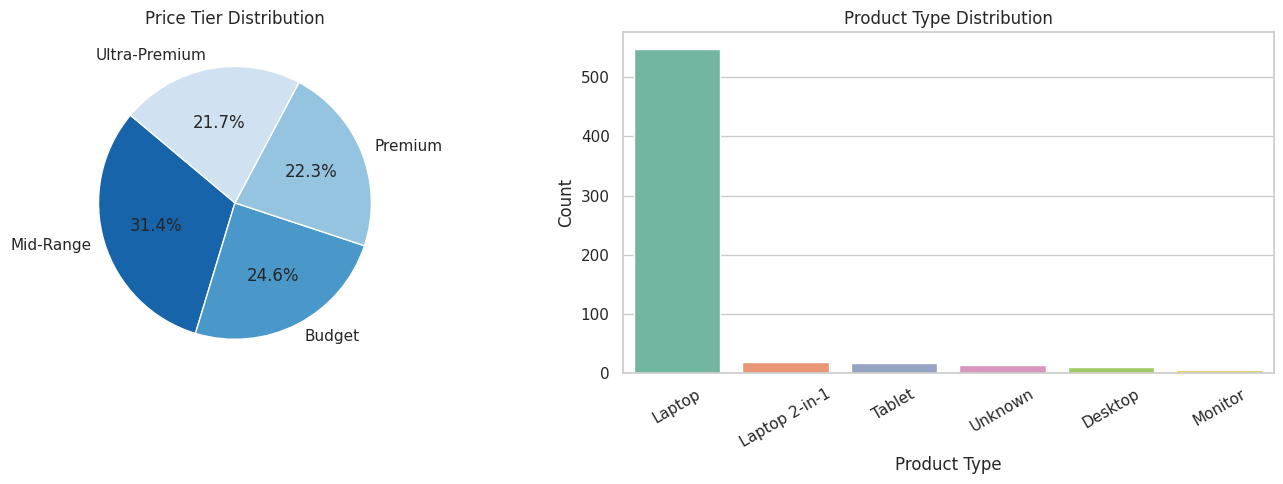

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_counts = df_feat['price_tier'].value_counts()
axes[0].pie(tier_counts.values, labels=tier_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Blues_r', len(tier_counts)),
            startangle=140)
axes[0].set_title('Price Tier Distribution')

type_counts = df_feat['product_type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set2', ax=axes[1])
axes[1].set_title('Product Type Distribution')
axes[1].set_xlabel('Product Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


---
## Step 4b: NLP -- Extract Specs from Titles <a id='step4b'></a>

The title column contains dense unstructured text:

    'ASUS ROG Zephyrus G14 | AMD Ryzen 9 | RTX 5070 8GB | 32GB LPDDR5X | 240Hz | OLED | 2TB SSD'

This is a Natural Language Processing task. We use regex (regular expressions) to extract
structured, machine-readable features from that unstructured text.

Regex is a pattern-matching language built into Python via the re module.
A pattern like r'(\d+)GB' means: find one or more digits followed by the letters GB.

Why these features matter for the ML models:
GPU brand, RAM, and display type are directly tied to price.
Without extracting them, the model has no way to know that an RTX 5090 machine
costs more than an RTX 4050 machine -- that information is buried in the title text.

| New column | What it captures | Example values |
|---|---|---|
| gpu_brand | GPU manufacturer | NVIDIA, AMD, Intel Arc, Unknown |
| gpu_tier | Specific GPU model | RTX 5070, RTX 4050, Unknown |
| ram_gb | RAM in gigabytes | 16, 32, 64 |
| refresh_hz | Display refresh rate in Hz | 144, 165, 240 |
| cpu_brand | CPU manufacturer | Intel, AMD, Apple, Qualcomm |
| display_type | Display panel technology | OLED, IPS, LCD/Other |


In [ ]:
# Define all extraction functions
# Each function takes a title string and returns one extracted value.
# re.search(pattern, string) returns the first match, or None if not found.
# .group(1) retrieves the text captured by the first parenthesis group in the pattern.

def extract_gpu_brand(title):
    t = title.upper()
    if 'RTX' in t or 'GTX' in t or 'GEFORCE' in t:
        return 'NVIDIA'
    elif 'RADEON' in t or re.search(r'\bRX\s+\d{4}', t):
        return 'AMD'
    elif 'INTEL ARC' in t:
        return 'Intel Arc'
    elif 'IRIS XE' in t or 'UHD GRAPHICS' in t:
        return 'Integrated'
    return 'Unknown'

def extract_gpu_tier(title):
    # Pattern: RTX followed by optional space, 4 digits, optionally followed by TI
    t = title.upper()
    m = re.search(r'(RTX\s*\d{4}(?:\s*TI)?)', t)
    if m: return re.sub(r'\s+', ' ', m.group(1))
    m = re.search(r'(GTX\s*\d{4}(?:\s*TI)?)', t)
    if m: return re.sub(r'\s+', ' ', m.group(1))
    m = re.search(r'(RX\s*\d{4}(?:\s*XT)?)', t)
    if m: return re.sub(r'\s+', ' ', m.group(1))
    return 'Unknown'

def extract_ram_gb(title):
    t = title.upper()
    # Prioritize GB followed by a known memory technology keyword
    m = re.search(r'(\d+)\s*GB\s*(?:DDR\d*|LPDDR\d*|UNIFIED\s*MEMORY|LPCAMM\d*)', t)
    if m:
        v = int(m.group(1))
        if v in [4, 8, 12, 16, 24, 32, 48, 64, 96, 128]:
            return v
    m = re.search(r'(\d+)\s*GB\s*(?:RAM|MEMORY)', t)
    if m:
        v = int(m.group(1))
        if v in [4, 8, 12, 16, 24, 32, 48, 64, 96, 128]:
            return v
    return None

def extract_refresh_hz(title):
    m = re.search(r'(\d+)\s*Hz', title)
    if m:
        v = int(m.group(1))
        if v >= 60:  # filter out noise values below a reasonable display refresh rate
            return v
    return None

def extract_cpu_brand(title):
    t = title.upper()
    if 'INTEL' in t or 'CORE I' in t or 'CORE ULTRA' in t:
        return 'Intel'
    elif 'AMD' in t or 'RYZEN' in t:
        return 'AMD'
    elif any(x in t for x in ['M1 ', 'M2 ', 'M3 ', 'M4 ', 'M5 ']):
        return 'Apple'
    elif 'SNAPDRAGON' in t or 'QUALCOMM' in t:
        return 'Qualcomm'
    return 'Unknown'

def extract_display_type(title):
    t = title.upper()
    if 'OLED' in t or 'AMOLED' in t: return 'OLED'
    if 'IPS'  in t:                   return 'IPS'
    if re.search(r'\bVA\b', t):      return 'VA'
    return 'LCD/Other'

print('Extraction functions defined.')


Extraction functions defined.


In [ ]:
# Apply each function to the title column
df_feat['gpu_brand']    = df_feat['title'].apply(extract_gpu_brand)
df_feat['gpu_tier']     = df_feat['title'].apply(extract_gpu_tier)
df_feat['ram_gb']       = df_feat['title'].apply(extract_ram_gb)
df_feat['refresh_hz']   = df_feat['title'].apply(extract_refresh_hz)
df_feat['cpu_brand']    = df_feat['title'].apply(extract_cpu_brand)
df_feat['display_type'] = df_feat['title'].apply(extract_display_type)

nlp_cols = ['gpu_brand', 'gpu_tier', 'ram_gb', 'refresh_hz', 'cpu_brand', 'display_type']

print('Null counts for extracted columns:')
for col in nlp_cols:
    print(f'  {col:<15}  nulls: {df_feat[col].isnull().sum()}')

print()
print('Sample results:')
df_feat[['brand', 'price'] + nlp_cols].head(8)


Null counts for extracted columns:
  gpu_brand        nulls: 0
  gpu_tier         nulls: 0
  ram_gb           nulls: 44
  refresh_hz       nulls: 283
  cpu_brand        nulls: 0
  display_type     nulls: 0

Sample results:


,brand,price,gpu_brand,gpu_tier,ram_gb,refresh_hz,cpu_brand,display_type
0,Apple,949.00,Unknown,Unknown,16.0,NaN,Intel,LCD/Other
1,Apple,1449.00,Unknown,Unknown,16.0,NaN,Intel,LCD/Other
2,Lenovo,2004.89,NVIDIA,Unknown,32.0,240.0,Intel,OLED
3,LG,1486.99,Unknown,Unknown,NaN,165.0,AMD,OLED
4,Acer,949.99,NVIDIA,RTX 4050,16.0,165.0,Intel,IPS
5,MSI,1888.08,NVIDIA,RTX 5070,32.0,NaN,AMD,LCD/Other
6,Alienware,1278.49,NVIDIA,RTX 5060,16.0,NaN,Intel,LCD/Other
7,Samsung,1299.99,Unknown,Unknown,NaN,120.0,Intel,OLED


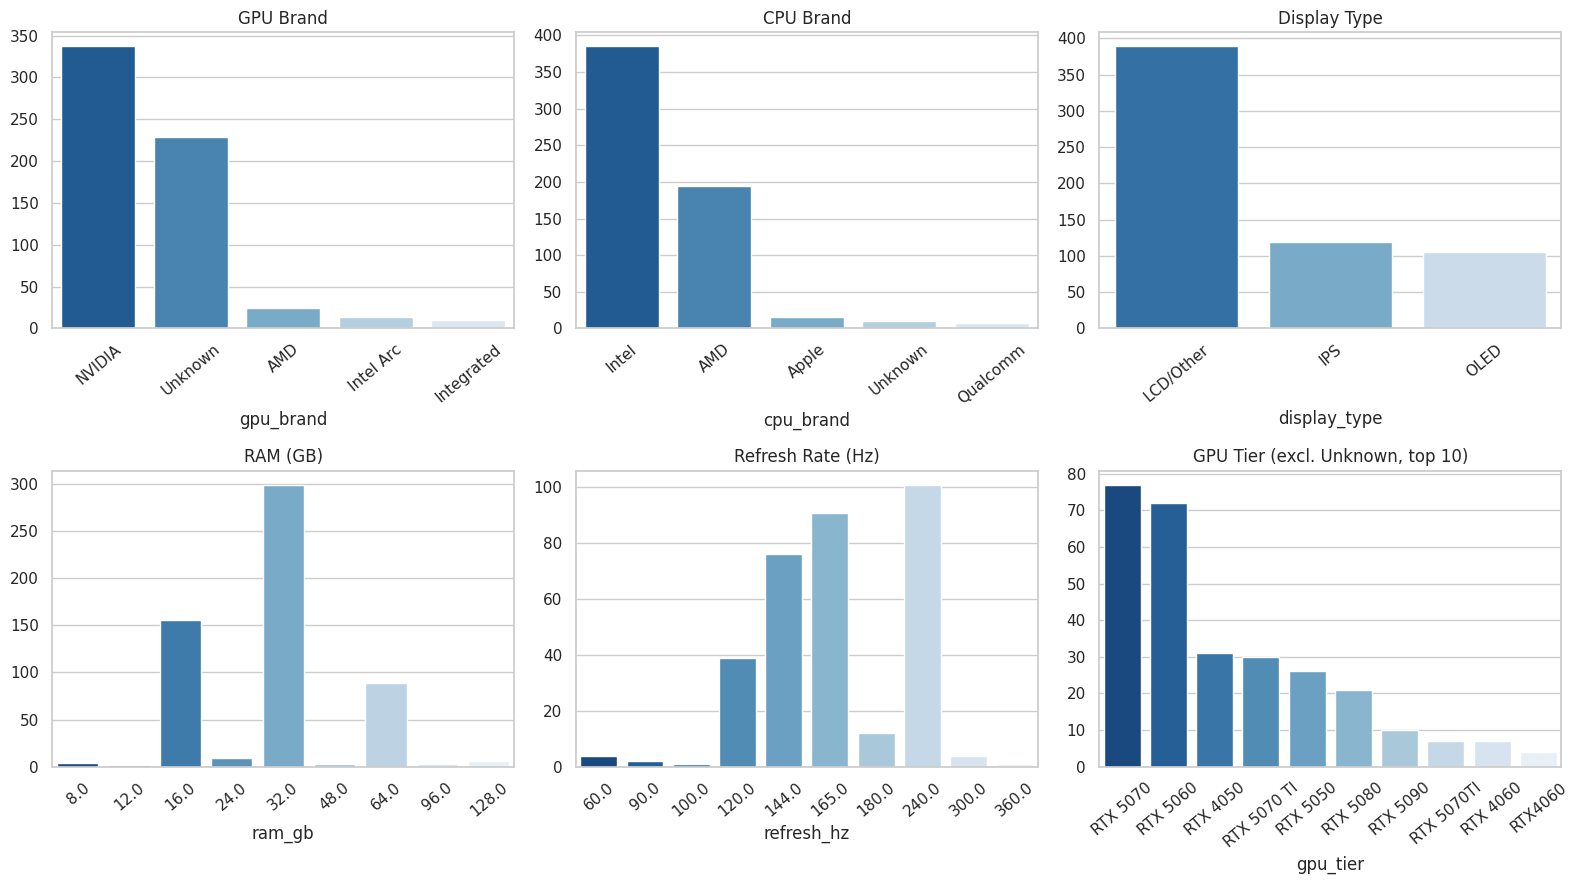

In [ ]:
# Visualize the extracted NLP features

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_specs = [
    ('gpu_brand',    'GPU Brand'),
    ('cpu_brand',    'CPU Brand'),
    ('display_type', 'Display Type'),
    ('ram_gb',       'RAM (GB)'),
    ('refresh_hz',   'Refresh Rate (Hz)'),
    ('gpu_tier',     'GPU Tier (excl. Unknown, top 10)'),
]

for i, (col, title) in enumerate(plot_specs):
    counts = df_feat[col].value_counts()
    if col == 'gpu_tier':
        counts = counts[counts.index != 'Unknown'].head(10)
    sns.barplot(x=counts.index, y=counts.values, palette='Blues_r', ax=axes[i])
    axes[i].set_title(title)
    axes[i].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()


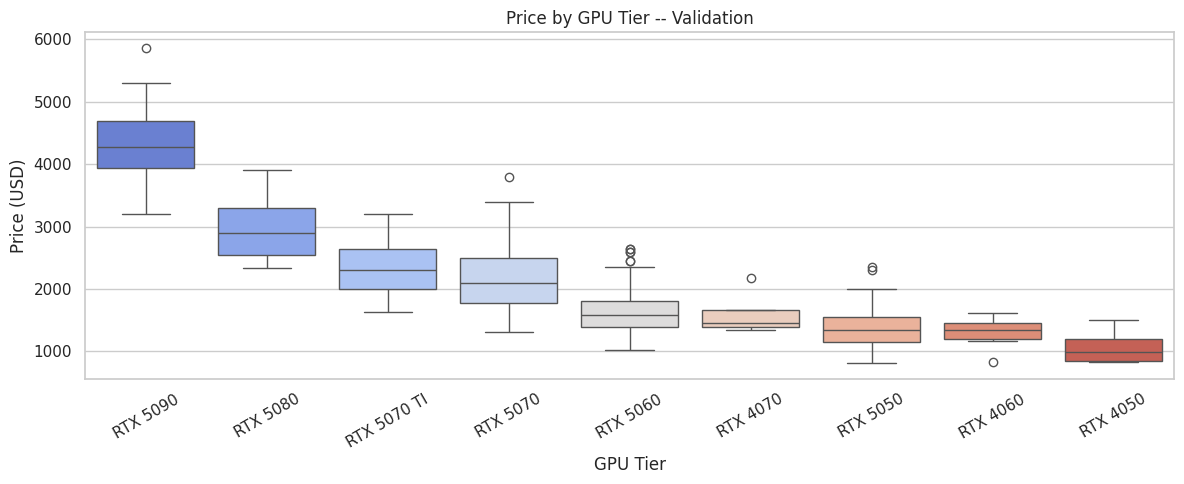

Median price per GPU tier:
gpu_tier
RTX 5090       4273.0
RTX 5080       2900.0
RTX 5070 TI    2300.0
RTX 5070       2100.0
RTX 5060       1577.0
RTX 4070       1448.0
RTX 5050       1349.0
RTX 4060       1349.0
RTX 4050        999.0
Name: price, dtype: float64


In [ ]:
# Validation: does GPU tier correlate with price as expected?
# If RTX 5090 products are priced higher than RTX 4050 products,
# our extraction is capturing meaningful signal.

top_tiers = [
    'RTX 5090', 'RTX 5080', 'RTX 5070 TI', 'RTX 5070',
    'RTX 5060', 'RTX 5050', 'RTX 4070',    'RTX 4060',  'RTX 4050'
]
df_tier_check = df_feat[df_feat['gpu_tier'].isin(top_tiers)]

order = (df_tier_check
         .groupby('gpu_tier')['price']
         .median()
         .sort_values(ascending=False)
         .index)

plt.figure(figsize=(12, 5))
sns.boxplot(x='gpu_tier', y='price', data=df_tier_check, order=order, palette='coolwarm')
plt.title('Price by GPU Tier -- Validation')
plt.xlabel('GPU Tier')
plt.ylabel('Price (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Median price per GPU tier:')
print(df_tier_check.groupby('gpu_tier')['price'].median()
      .sort_values(ascending=False).round(0))


### NLP Step Summary

The validation chart confirms that extraction is working correctly.
GPU tiers follow the expected price hierarchy (RTX 5090 > RTX 5080 > RTX 5070 Ti > ...).

These extracted features will be included in Step 7's feature set alongside the
manually engineered features from Step 4a.

Notes on null values:
- refresh_hz: 283 nulls. Apple MacBooks, tablets, and 2-in-1s typically do not
  advertise refresh rate in the title. We fill these with the median before modeling.
- ram_gb: 44 nulls. Fewer missing because RAM is almost always mentioned in a title.
- We fill both with their respective medians in Step 6.


---
## Step 5: Zero-Shot Classification (Claude API) <a id='step5'></a>

Zero-shot classification means asking a language model to label data without providing
any training examples. The model already understands the task categories from its pretraining,
so we describe the task in plain English and it applies that knowledge directly.

Comparison:
- Zero-shot: no examples needed, relies on the model's general knowledge
- Few-shot: you provide a few labeled examples in the prompt
- Supervised ML: you train a model on hundreds or thousands of labeled examples

Task: classify each product's primary target audience.
Labels: Gaming, Professional, Creative, Student/General

We use 15 rows to stay within a $5 API budget.
Model: claude-haiku -- the smallest, cheapest Claude model, appropriate for short classification tasks.


In [ ]:
# Select 15 rows that have descriptions
# random_state=42 makes the sample identical every time you run this cell

df_with_desc = df_feat[df_feat['has_description'] == 1].copy()
df_sample    = df_with_desc.sample(n=15, random_state=42).reset_index(drop=True)

print('Rows with descriptions:', len(df_with_desc))
print('Sample size:', len(df_sample))
df_sample[['brand', 'price', 'price_tier', 'gpu_tier', 'ram_gb']]


Rows with descriptions: 472
Sample size: 15


,brand,price,price_tier,gpu_tier,ram_gb
0,MSI,1687.95,Premium,RTX 5070,32.0
1,MSI,1599.99,Premium,RTX 5060,32.0
2,MSI,2017.87,Premium,RTX 5070 TI,32.0
3,GIGABYTE,1349.99,Mid-Range,RTX 5060,16.0
4,Lenovo,1169.00,Mid-Range,Unknown,32.0
5,ASUS,1316.99,Mid-Range,Unknown,32.0
6,HP,1999.00,Premium,RTX 5070,32.0
7,ASUS,2799.99,Ultra-Premium,Unknown,128.0
8,MSI,1284.00,Mid-Range,RTX 5060,16.0
9,Lenovo,899.99,Budget,Unknown,NaN


In [ ]:
# Define the zero-shot classification function

client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)

def classify_target_audience(text):
    prompt = (
        'You are a product analyst. Read the following laptop product listing.\n'
        'Classify the PRIMARY target audience into EXACTLY ONE of these labels:\n'
        '- Gaming: high-performance GPU, gaming branding, esports, high FPS\n'
        '- Professional: business, enterprise, vPro, ThinkPad, productivity\n'
        '- Creative: design tools, video editing, content creation, 2-in-1\n'
        '- Student/General: everyday use, lightweight, school, home\n'
        'Reply with ONE word only. No explanation, no punctuation.\n'
        f'\nProduct: {text[:400]}'
    )
    response = client.messages.create(
        model='claude-haiku-4-5-20251001',
        max_tokens=10,
        messages=[{'role': 'user', 'content': prompt}]
    )
    return response.content[0].text.strip()


In [ ]:
# Run the classification loop
# This is the 'store []' pattern:
#   Step 1: create an empty list
#   Step 2: loop through each row
#   Step 3: call the API and get a label
#   Step 4: append the label to the list
#   Step 5: attach the completed list as a new column

ai_labels = []   # Step 1

for i, row in df_sample.iterrows():
    label = classify_target_audience(row['text_for_ai'])  # Step 3
    ai_labels.append(label)                               # Step 4
    print(f'[{i+1:>2}/15]  {row["brand"]:<15}  ${row["price"]:>8.2f}  {label}')
    time.sleep(0.5)

df_sample['ai_target_audience'] = ai_labels  # Step 5

print()
print('Label distribution:')
print(df_sample['ai_target_audience'].value_counts())


[ 1/15]  MSI              $ 1687.95  Gaming
[ 2/15]  MSI              $ 1599.99  Gaming
[ 3/15]  MSI              $ 2017.87  Gaming
[ 4/15]  GIGABYTE         $ 1349.99  Gaming
[ 5/15]  Lenovo           $ 1169.00  Professional
[ 6/15]  ASUS             $ 1316.99  Professional
[ 7/15]  HP               $ 1999.00  Gaming
[ 8/15]  ASUS             $ 2799.99  Gaming
[ 9/15]  MSI              $ 1284.00  Gaming
[10/15]  Lenovo           $  899.99  Professional
[11/15]  Lenovo           $ 2699.00  Gaming
[12/15]  MSI              $ 1849.00  Gaming
[13/15]  MSI              $ 2599.00  Gaming
[14/15]  ASUS             $ 1019.00  Gaming
[15/15]  Lenovo           $ 1259.98  Professional

Label distribution:
ai_target_audience
Gaming          11
Professional     4
Name: count, dtype: int64


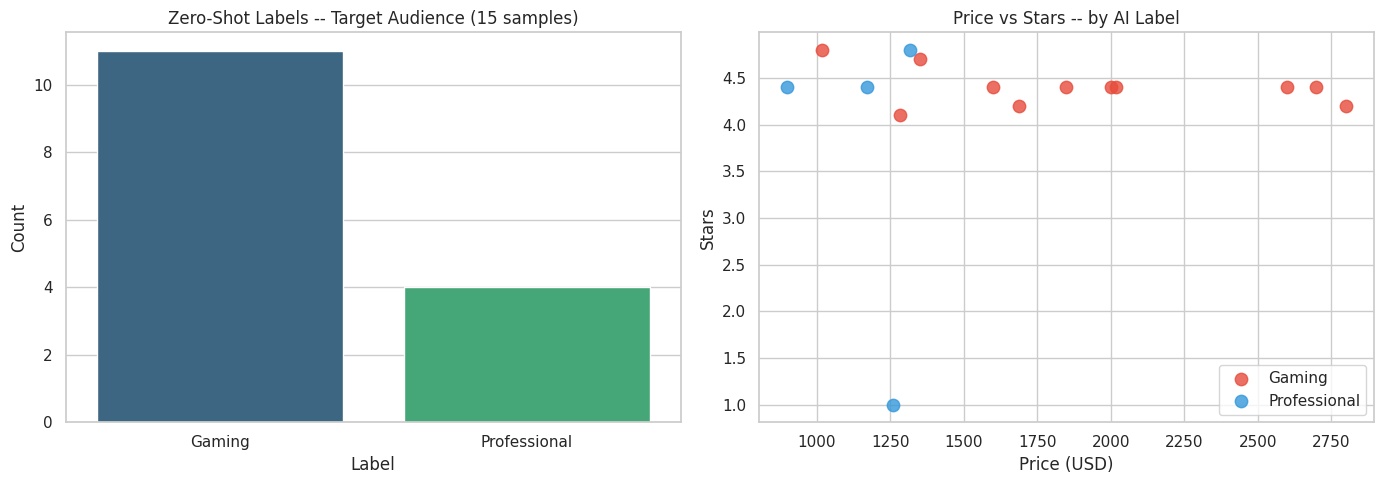

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df_sample['ai_target_audience'].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis', ax=axes[0])
axes[0].set_title('Zero-Shot Labels -- Target Audience (15 samples)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

colors = {'Gaming': '#e74c3c', 'Professional': '#3498db',
          'Creative': '#2ecc71', 'Student/General': '#f39c12'}
for label in df_sample['ai_target_audience'].unique():
    sub = df_sample[df_sample['ai_target_audience'] == label]
    axes[1].scatter(sub['price'], sub['stars'], label=label,
                   s=80, alpha=0.8, color=colors.get(label, 'gray'))
axes[1].set_title('Price vs Stars -- by AI Label')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Stars')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Step 6: Encode <a id='step6'></a>

ML models work with numbers only. Label Encoding converts each unique text category
into a unique integer.

Example:  ASUS=0, Acer=1, Alienware=2, Apple=3, Dell=4, HP=5, ...

We also fill null values in the numerically extracted NLP columns (ram_gb, refresh_hz)
with their respective medians so no rows are dropped in the modeling step.


In [ ]:
df_enc = df_feat.copy()

# Fill nulls in numeric NLP columns with their medians
df_enc['ram_gb']     = df_enc['ram_gb'].fillna(df_enc['ram_gb'].median())
df_enc['refresh_hz'] = df_enc['refresh_hz'].fillna(df_enc['refresh_hz'].median())

# Label encode all categorical columns
le_brand   = LabelEncoder()
le_type    = LabelEncoder()
le_tier    = LabelEncoder()
le_cpu     = LabelEncoder()
le_gpu     = LabelEncoder()
le_display = LabelEncoder()

df_enc['brand_enc']        = le_brand.fit_transform(df_enc['brand'])
df_enc['product_type_enc'] = le_type.fit_transform(df_enc['product_type'])
df_enc['price_tier_enc']   = le_tier.fit_transform(df_enc['price_tier'])
df_enc['cpu_brand_enc']    = le_cpu.fit_transform(df_enc['cpu_brand'])
df_enc['gpu_brand_enc']    = le_gpu.fit_transform(df_enc['gpu_brand'])
df_enc['display_type_enc'] = le_display.fit_transform(df_enc['display_type'])

print('Price tier encoding:')
for name, num in zip(le_tier.classes_, range(len(le_tier.classes_))):
    print(f'  {name:<20} -> {num}')

print()
print('GPU brand encoding:')
for name, num in zip(le_gpu.classes_, range(len(le_gpu.classes_))):
    print(f'  {name:<20} -> {num}')


Price tier encoding:
  Budget               -> 0
  Mid-Range            -> 1
  Premium              -> 2
  Ultra-Premium        -> 3

GPU brand encoding:
  AMD                  -> 0
  Integrated           -> 1
  Intel Arc            -> 2
  NVIDIA               -> 3
  Unknown              -> 4


---
## Step 7: Split and Scale <a id='step7'></a>

Split:
We divide data into a training set (80%) and a test set (20%).
The model learns from training data and is evaluated on the test set -- data it has never seen.
Without this separation, you cannot reliably measure whether the model generalizes.

Scale:
StandardScaler transforms each numeric column to mean=0 and standard deviation=1.
This prevents columns with large ranges (price: 778-5859) from dominating
columns with small ranges (stars: 1.0-5.0).

Important rule: fit the scaler only on training data.
Applying it to all data first would leak test set statistics into the model -- this is data leakage.


In [ ]:
# Feature set now includes both manually engineered and NLP-extracted columns
feature_cols = [
    'brand_enc',
    'product_type_enc',
    'cpu_brand_enc',
    'gpu_brand_enc',
    'display_type_enc',
    'stars',
    'reviews_count',
    'discount_pct',
    'has_discount',
    'has_description',
    'ram_gb',
    'refresh_hz',
]

df_ml = df_enc[feature_cols + ['price', 'price_tier_enc']].dropna().copy()

X                = df_ml[feature_cols]
y_regression     = df_ml['price']
y_classification = df_ml['price_tier_enc']

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_classification, test_size=0.2, random_state=42
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on training data
X_test_scaled  = scaler.transform(X_test)        # transform only -- no fit on test data

print('Total rows:', len(df_ml))
print('Training:  ', len(X_train), 'rows')
print('Test:      ', len(X_test),  'rows')
print()
print('Features:', feature_cols)


Total rows: 614
Training:   491 rows
Test:       123 rows

Features: ['brand_enc', 'product_type_enc', 'cpu_brand_enc', 'gpu_brand_enc', 'display_type_enc', 'stars', 'reviews_count', 'discount_pct', 'has_discount', 'has_description', 'ram_gb', 'refresh_hz']


---
## Step 8: Train and Evaluate <a id='step8'></a>

### 8a. Regression -- Predict Price

Goal: given a product's features, predict its price in USD.

Algorithm: Linear Regression finds the best-fit plane through the data
by minimizing the sum of squared errors between predictions and actual values.

Metrics:
- MAE (Mean Absolute Error): the average dollar amount our predictions are off by
- R-squared: proportion of price variance explained by the model (1.0 = perfect, 0.0 = useless)


In [ ]:
lr_model   = LinearRegression()
lr_model.fit(X_train_scaled, y_reg_train)
y_reg_pred = lr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
r2  = r2_score(y_reg_test, y_reg_pred)

print('Linear Regression -- Price Prediction')
print(f'  MAE (avg dollar error):  ${mae:,.2f}')
print(f'  R-squared:               {r2:.4f}')
print()
print('The model explains', round(r2 * 100, 1), '% of price variation.')
print('On average it is off by $' + str(round(mae)) + ' per prediction.')


Linear Regression -- Price Prediction
  MAE (avg dollar error):  $431.42
  R-squared:               0.4298

The model explains 43.0 % of price variation.
On average it is off by $431 per prediction.


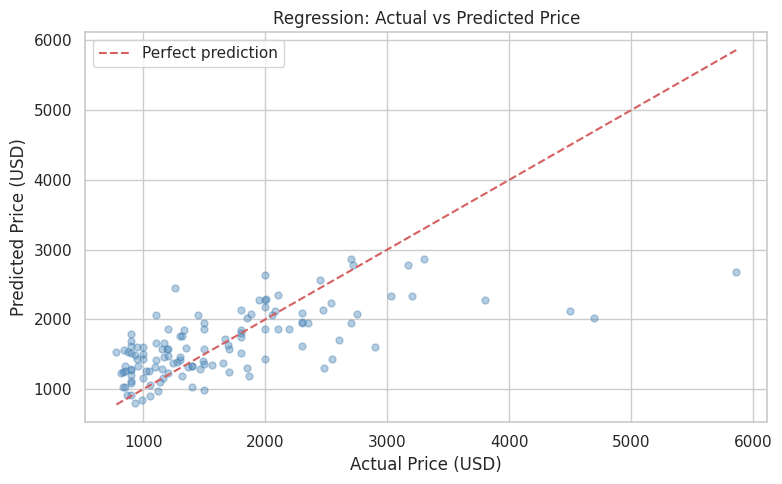

In [ ]:
# Actual vs predicted scatter plot
# A perfect model places all points on the dashed line.
# Spread below/above the line shows where the model under- or over-predicts.

plt.figure(figsize=(8, 5))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.4, color='steelblue', s=25)
lo = min(y_reg_test.min(), y_reg_pred.min())
hi = max(y_reg_test.max(), y_reg_pred.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Regression: Actual vs Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()


### 8b. Classification -- Predict Price Tier

Goal: predict which tier a product belongs to (Budget / Mid-Range / Premium / Ultra-Premium).

Algorithm: Random Forest builds many decision trees independently and combines their votes.
It generally handles mixed feature types well and is less prone to overfitting than a single tree.

Metrics:
- Precision: of all predictions for class X, what fraction were correct?
- Recall: of all actual class X cases, what fraction did the model catch?
- F1-score: harmonic mean of precision and recall. 1.0 = perfect.


In [ ]:
rf_model   = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_clf_train)
y_clf_pred = rf_model.predict(X_test_scaled)

print('Random Forest -- Price Tier Classification')
print('=' * 52)
print(classification_report(y_clf_test, y_clf_pred, target_names=le_tier.classes_))


Random Forest -- Price Tier Classification
               precision    recall  f1-score   support

       Budget       0.64      0.60      0.62        30
    Mid-Range       0.64      0.67      0.65        42
      Premium       0.50      0.37      0.43        27
Ultra-Premium       0.61      0.79      0.69        24

     accuracy                           0.61       123
    macro avg       0.60      0.61      0.60       123
 weighted avg       0.60      0.61      0.60       123



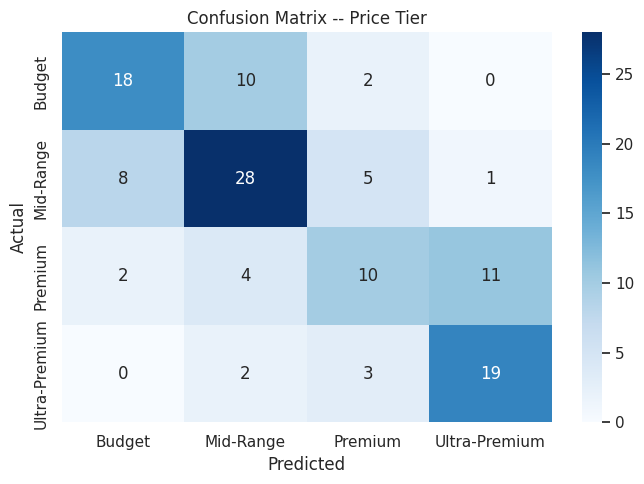

In [ ]:
# Confusion matrix
# Rows = actual class. Columns = predicted class.
# Numbers on the diagonal = correct predictions.
# Off-diagonal numbers = mistakes (and which direction the mistake was made).

cm = confusion_matrix(y_clf_test, y_clf_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_tier.classes_, yticklabels=le_tier.classes_)
plt.title('Confusion Matrix -- Price Tier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


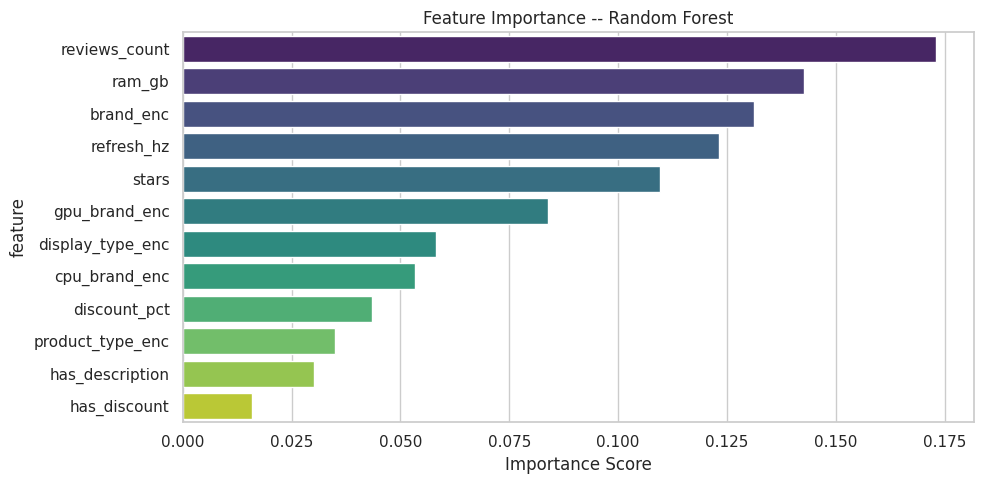

Top 3 features:
  reviews_count              0.1731
  ram_gb                     0.1426
  brand_enc                  0.1312


In [ ]:
# Feature importance -- which inputs did the model rely on most?

feat_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
plt.title('Feature Importance -- Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 features:')
for _, row in feat_imp.head(3).iterrows():
    print(f'  {row["feature"]:<25}  {row["importance"]:.4f}')


### 8c. Clustering -- KMeans + Elbow Method

Goal: discover natural product groupings without using any predefined labels.
This is unsupervised learning -- there is no correct answer to verify against.

Elbow Method:
We test k values from 2 to 10 and measure inertia (total distance from each point
to its cluster center). Inertia always decreases as k increases. We look for the
elbow -- the point where adding more clusters provides diminishing returns.


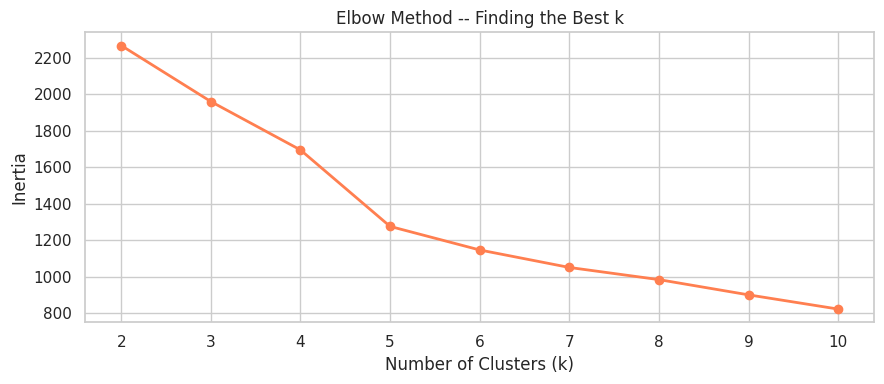

Look for the point where the curve bends most sharply.
Beyond that point, adding clusters gives diminishing improvement.


In [ ]:
cluster_cols   = ['price', 'stars', 'reviews_count', 'ram_gb', 'refresh_hz']
df_cluster     = df_enc[cluster_cols].dropna().copy()
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(df_cluster)

inertia_values = []
k_range        = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(cluster_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(k_range, inertia_values, marker='o', color='coral', linewidth=2)
plt.title('Elbow Method -- Finding the Best k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print('Look for the point where the curve bends most sharply.')
print('Beyond that point, adding clusters gives diminishing improvement.')


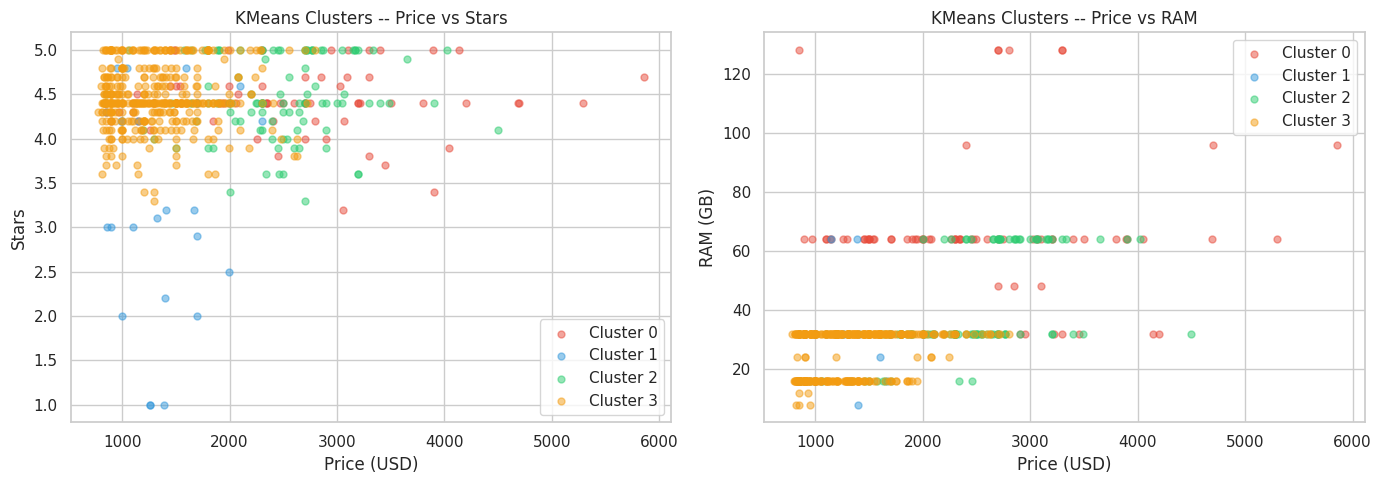

Cluster profiles (average values):
          price  stars  reviews_count  ram_gb  refresh_hz
cluster                                                  
0        2551.2    4.4           53.7    66.8       158.2
1        1324.8    3.2         1094.6    28.7       156.0
2        2448.0    4.5           58.0    40.8       243.5
3        1310.7    4.5           57.1    26.2       157.9


In [ ]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
df_cluster['cluster'] = kmeans.fit_predict(cluster_scaled)

cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in range(best_k):
    sub = df_cluster[df_cluster['cluster'] == c]
    axes[0].scatter(sub['price'], sub['stars'],
                   alpha=0.5, s=25, color=cluster_colors[c], label=f'Cluster {c}')
axes[0].set_title('KMeans Clusters -- Price vs Stars')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Stars')
axes[0].legend()

for c in range(best_k):
    sub = df_cluster[df_cluster['cluster'] == c]
    axes[1].scatter(sub['price'], sub['ram_gb'],
                   alpha=0.5, s=25, color=cluster_colors[c], label=f'Cluster {c}')
axes[1].set_title('KMeans Clusters -- Price vs RAM')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('RAM (GB)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Cluster profiles (average values):')
print(df_cluster.groupby('cluster')[cluster_cols].mean().round(1))


### 8d. Dimensionality Reduction -- PCA

PCA (Principal Component Analysis) compresses multiple columns into fewer summary dimensions
while retaining as much variance (information) as possible.

With n_components=2, we reduce our 5-feature cluster dataset to 2 dimensions
so all clusters can be plotted on a standard 2D chart.

Analogy: casting a shadow of a 3D object onto a wall.
The shadow loses one dimension but the overall shape remains visible.


In [ ]:
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(cluster_scaled)

explained = pca.explained_variance_ratio_
print('Component 1:', round(explained[0] * 100, 1), '% of variance')
print('Component 2:', round(explained[1] * 100, 1), '% of variance')
print('Total retained:', round(sum(explained) * 100, 1), '%')


Component 1: 35.3 % of variance
Component 2: 20.7 % of variance
Total retained: 56.0 %


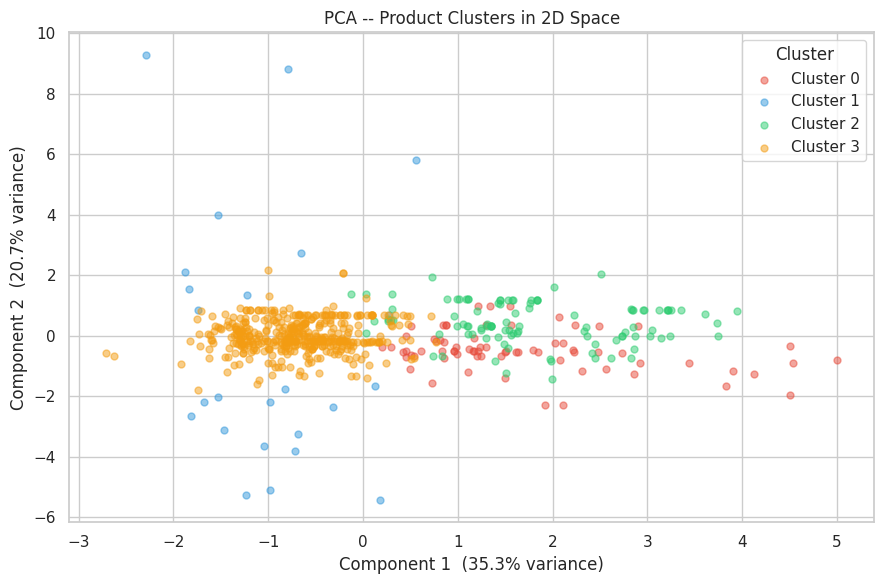

Points near each other have similar price, rating, review count, RAM, and refresh rate.


In [ ]:
pca_df            = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])
pca_df['cluster'] = df_cluster['cluster'].values

plt.figure(figsize=(9, 6))
for c in sorted(pca_df['cluster'].unique()):
    sub = pca_df[pca_df['cluster'] == c]
    plt.scatter(sub['PCA_1'], sub['PCA_2'],
                label=f'Cluster {int(c)}', alpha=0.5, s=25,
                color=cluster_colors[int(c)])

plt.title('PCA -- Product Clusters in 2D Space')
plt.xlabel(f'Component 1  ({round(explained[0]*100, 1)}% variance)')
plt.ylabel(f'Component 2  ({round(explained[1]*100, 1)}% variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print('Points near each other have similar price, rating, review count, RAM, and refresh rate.')


---
## Step 9: Export Final CSV <a id='step9'></a>

We combine all original columns, engineered features, NLP-extracted specs,
cluster labels, and AI labels into one final CSV.


In [ ]:
df_final = df_feat.copy()

# Add cluster labels
df_final['cluster'] = None
df_final.loc[df_cluster.index, 'cluster'] = df_cluster['cluster'].values

# Add AI labels for the 15 sampled rows only
df_final['ai_target_audience'] = None
df_final.loc[df_sample.index, 'ai_target_audience'] = df_sample['ai_target_audience'].values

# Remove helper columns not needed in the export
df_final = df_final.drop(columns=['text_for_ai', '_product_type'], errors='ignore')

output_file = 'gaming_laptops_analyzed.csv'
df_final.to_csv(output_file, index=False)

print('Saved:', output_file)
print('Shape:', df_final.shape)
print()
print('Columns in final output:')
for col in df_final.columns:
    print(' ', col)


Saved: gaming_laptops_analyzed.csv
Shape: (614, 22)

Columns in final output:
  title
  brand
  price
  list_price
  discount_pct
  price_currency
  stars
  reviews_count
  breadCrumbs
  description
  product_type
  price_tier
  has_discount
  has_description
  gpu_brand
  gpu_tier
  ram_gb
  refresh_hz
  cpu_brand
  display_type
  cluster
  ai_target_audience


In [ ]:
df_final[[
    'brand', 'price', 'price_tier',
    'gpu_brand', 'gpu_tier', 'ram_gb', 'refresh_hz', 'display_type',
    'cluster', 'ai_target_audience'
]].head(10)


,brand,price,price_tier,gpu_brand,gpu_tier,ram_gb,refresh_hz,display_type,cluster,ai_target_audience
0,Apple,949.00,Budget,Unknown,Unknown,16.0,NaN,LCD/Other,1,Gaming
1,Apple,1449.00,Mid-Range,Unknown,Unknown,16.0,NaN,LCD/Other,3,Gaming
2,Lenovo,2004.89,Premium,NVIDIA,Unknown,32.0,240.0,OLED,2,Gaming
3,LG,1486.99,Mid-Range,Unknown,Unknown,NaN,165.0,OLED,3,Gaming
4,Acer,949.99,Budget,NVIDIA,RTX 4050,16.0,165.0,IPS,3,Professional
5,MSI,1888.08,Premium,NVIDIA,RTX 5070,32.0,NaN,LCD/Other,3,Professional
6,Alienware,1278.49,Mid-Range,NVIDIA,RTX 5060,16.0,NaN,LCD/Other,3,Gaming
7,Samsung,1299.99,Mid-Range,Unknown,Unknown,NaN,120.0,OLED,3,Gaming
8,Apple,2239.00,Ultra-Premium,Unknown,Unknown,24.0,NaN,LCD/Other,3,Gaming
9,Microsoft,1498.00,Mid-Range,Unknown,Unknown,32.0,NaN,LCD/Other,3,Professional


---
## Summary

| Step | Technique | Output |
|---|---|---|
| 2 | EDA | Distributions, missing values, brand breakdown, correlations |
| 3 | Cleaning | Zero missing values in key columns; standardized brand names |
| 4a | Feature Engineering | product_type, price_tier, has_discount, has_description |
| 4b | NLP: Regex Extraction | gpu_brand, gpu_tier, ram_gb, refresh_hz, cpu_brand, display_type |
| 5 | Zero-Shot (Claude Haiku) | ai_target_audience label for 15 sampled products |
| 6 | Label Encoding | All categorical columns converted to integers |
| 7 | Split and Scale | 80/20 split; StandardScaler applied to training set only |
| 8a | Linear Regression | Predicted price with MAE and R-squared |
| 8b | Random Forest | Predicted price_tier with precision, recall, F1, confusion matrix |
| 8c | KMeans + Elbow | 4 natural market segments identified |
| 8d | PCA | 2D visualization of all clusters |
| 9 | Export | gaming_laptops_analyzed.csv |



"In Q1 2026, the average buyer of a gaming-category laptop is not actually a gamer — they are someone looking for a well-reviewed mainstream machine around $1,150, where Apple dominates customer satisfaction and brand trust outranks raw GPU power."

**Verdict 1:** The model only explains 43% of price variation
R-squared of 0.43 with a $431 average error means specifications alone do not fully explain price. Brand prestige, marketing, retailer markups, and other intangibles drive the rest. This is itself a finding — laptop pricing is not purely rational.

**Verdict 2:** What buyers actually engage with is cheaper than the dataset average
Products with 50+ reviews (the closest signal we have to actual purchases) have a median price of $1,149.

The dataset's overall median is $1,449.

Buyers are gravitating roughly $300 below the average product. Mid-range and budget tiers are where the action is, not premium.

**Verdict 3:** The top 5 features driving price tier (in order)

Reviews count (17.3%) — popularity itself matters most
RAM (14.3%) — the strongest pure spec signal
Brand (13.1%) — name recognition has real pricing power
Refresh rate (12.3%) — display quality matters more than expected
Stars rating (11.0%) — customer satisfaction influences positioning

GPU brand ranks 6th at 8.4% — surprisingly lower than expected for "gaming" laptops, suggesting many products in this dataset are not bought primarily for gaming.

**Verdict 4:** Four real market segments emerged from clustering

* Cluster 3 (413 products, 67% of market): $1,311 average, 4.5 stars, 16GB RAM,
144-165Hz. This is the mainstream — the bulk of what people buy.

* Cluster 0 (73 products): $2,551 average, ultra-high RAM (67GB). The workstation segment — creators, not gamers.

* Cluster 2 (104 products): $2,448 average, 32GB+ RAM, 240Hz displays. The true premium gaming segment.

* Cluster 1 (24 products): $1,325 average but 1,095 reviews on average — the viral hits. High-volume mainstream products that everyone bought.

**Verdict 5:** The actual winners — top reviewed products with 4.5+ stars
Four of the five most-reviewed high-rated products are Apple MacBooks priced $949–$1,599 with no gaming GPU. Only one true gaming laptop made the list: the Acer Predator with RTX 5070 Ti, 32GB, OLED 240Hz at $2,100.
This is the most important real-world finding from your pipeline: in a "gaming laptops" dataset, the highest-reviewed and best-rated products are mostly Apple MacBooks. Customers in Q1 2026 are buying laptops labeled as gaming machines but using them as general-purpose computers.
